# Applied Statistics for Data Science

# Chapter 3: Sampling & Estimators

by Gal Arav M.Sc. © 2026
Licensed under the MIT LICENSE

## Learning Objectives  

This notebook accompanies the book's Chapter 3 with these objectives:

- Learn the concepts of point estimates, interval estimates and hypothesis testing
- Use simulated data to explore sampling variability and estimator performance
- Explain what estimators are and how they behave across repeated samples
- Interpret and visualize sampling distributions for common statistics
- Distinguish between standard deviation and standard error
- Understand the role of the Central Limit Theorem in uncertainty quantification
- Evaluate estimator properties such as bias, variance, consistency, and MSE






In [ ]:
# Utility function to save a high‑resolution figure for the textbook
# Images are saved temporarily in Google Colab and disappear when the session ends
import matplotlib.pyplot as plt
import os

def export_plot(fig, plot_id, dpi=300, width=8, height=5, outdir="exports"):
    fig.set_size_inches(width, height)
    fig.subplots_adjust(left=0.12, right=0.95, top=0.87, bottom=0.15)
    os.makedirs(outdir, exist_ok=True)
    fig.savefig(f"{outdir}/{plot_id}.png", dpi=dpi, bbox_inches=None, pad_inches=0.45)

## Standard Error as Uncertainty

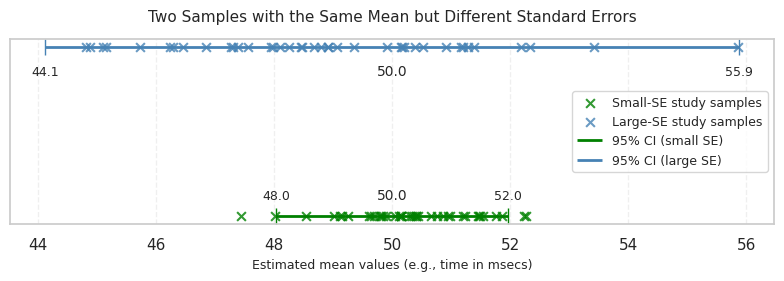

In [ ]:
# ============================================================
# Two studies with same mean but different standard errors
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm  # (not strictly needed, but fine to keep)

np.random.seed(0)

# ----------------------------------------------------
# Two studies: same mean, different SE
# ----------------------------------------------------
mean = 50

# Small SE study (more precise)
se_small = 1.0
ci_small = (mean - 1.96 * se_small, mean + 1.96 * se_small)

# Large SE study (less precise)
se_large = 3.0
ci_large = (mean - 1.96 * se_large, mean + 1.96 * se_large)

# Simulated repeated measurements
samples_small = np.random.normal(mean, se_small, size=40)
samples_large = np.random.normal(mean, se_large, size=40)

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 3))

y_small = 1.0
y_large = 1.3   # small vertical gap

# Repeated measurements
ax.scatter(
    samples_small,
    np.full_like(samples_small, y_small),
    marker="x",
    s=40,
    color="green",
    alpha=0.8,
    label="Small-SE study samples"
)

ax.scatter(
    samples_large,
    np.full_like(samples_large, y_large),
    marker="x",
    s=40,
    color="steelblue",
    alpha=0.8,
    label="Large-SE study samples"
)

# CI lines
ax.hlines(y_small, ci_small[0], ci_small[1], color="green", linewidth=2, label="95% CI (small SE)")
ax.hlines(y_large, ci_large[0], ci_large[1], color="steelblue", linewidth=2, label="95% CI (large SE)")

# Endpoints
ax.plot([ci_small[0], ci_small[1]], [y_small, y_small], "|", color="green", markersize=12)
ax.plot([ci_large[0], ci_large[1]], [y_large, y_large], "|", color="steelblue", markersize=12)

# Labels on mean and CI endpoints
ax.text(mean, y_small + 0.03, f"{mean:.1f}", ha="center", fontsize=10)
ax.text(mean, y_large - 0.05, f"{mean:.1f}", ha="center", fontsize=10)

ax.text(ci_small[0], y_small + 0.03, f"{ci_small[0]:.1f}", ha="center", fontsize=9)
ax.text(ci_small[1], y_small + 0.03, f"{ci_small[1]:.1f}", ha="center", fontsize=9)

ax.text(ci_large[0], y_large - 0.05, f"{ci_large[0]:.1f}", ha="center", fontsize=9)
ax.text(ci_large[1], y_large - 0.05, f"{ci_large[1]:.1f}", ha="center", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("Estimated mean values (e.g., time in msecs)", fontsize=9)
ax.set_title("Two Samples with the Same Mean but Different Standard Errors", y=1.05, fontsize=11)
ax.legend(loc="center right", fontsize=9)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
export_plot(fig, "sim_se_uncertainty", height=3)

## Example Calculation: SE → Critical Value → MoE → CI

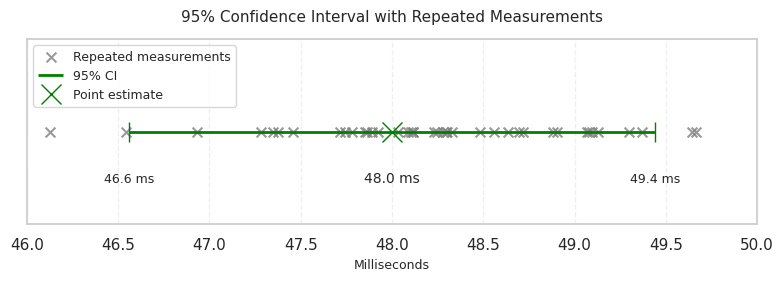

In [ ]:
# ============================================================
# 95% Confidence Interval with Repeated Measurements
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# Given values
# -----------------------------
estimate = 48.0
se_percent = 1.53 / 100
critical = norm.ppf(0.975)

margin = critical * se_percent
lower = estimate * (1 - margin)
upper = estimate * (1 + margin)

# -----------------------------
# Simulate repeated measurements
# -----------------------------
np.random.seed(0)
n_samples = 40
samples = np.random.normal(
    loc=estimate,
    scale=estimate * se_percent,
    size=n_samples
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 3))

y = 1.0  # everything sits on this line

# Repeated measurements
ax.scatter(
    samples,
    np.full_like(samples, y),
    marker='x',
    s=50,
    color="gray",
    alpha=0.8,
    label="Repeated measurements"
)

# CI line
ax.hlines(y, lower, upper, color="green", linewidth=2, label="95% CI")

# Point estimate
ax.plot(
    estimate, y,
    'x',
    color="green",
    markersize=15,
    markerfacecolor='none',
    label="Point estimate"
)

# Endpoints
ax.plot([lower, upper], [y, y], '|', color="green", markersize=15)

# Labels
ax.text(estimate, y - 0.03, f"{estimate:.1f} ms", ha="center", fontsize=10)
ax.text(lower,   y - 0.03, f"{lower:.1f} ms",   ha="center", fontsize=9)
ax.text(upper,   y - 0.03, f"{upper:.1f} ms",   ha="center", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("Milliseconds", fontsize=9)
ax.set_xlim(46, 50)
ax.set_title("95% Confidence Interval with Repeated Measurements", y=1.05, fontsize=11)
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
export_plot(fig, "sim_confidence_interval", height=3)

## Simulated Population Data Generation

In [ ]:
# ============================================================
# Setup and canonical dataset
# ============================================================

# This setup block constructs a synthetic population that we will repeatedly sample from.

# Prepare environment, set a reproducible seed, and create a single canonical synthetic dataset
# that will be reused for demonstrations.

# The dataset contains a skewed numeric outcome, a categorical
# stratum "group", a time column, and a binary label for demonstration.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold

N = 10000

SEED = 42
np.random.seed(SEED)
sns.set(style="whitegrid", context="notebook", rc={"figure.figsize": (10, 4)})

# Generate an hourly timestamp column to mimic a real dataset with temporal structure.
time = pd.date_range("2020-01-01", periods=N, freq="h")

# Create a categorical subgroup variable with intentionally imbalanced probabilities.
# This gives us realistic strata for later demonstrations of stratified sampling,
# representativeness checks, and subgroup-specific diagnostics.
group = np.random.choice(
    ["A", "B", "C", "D"],
    size=N,
    p=[0.6, 0.2, 0.15, 0.05]   # strong imbalance is intentional
)

# Generate a skewed numeric outcome using a lognormal distribution.
# The heavy right tail makes CLT demonstrations, bootstrap intervals,
# and power simulations more visually meaningful.
outcome = np.random.lognormal(mean=1.0, sigma=1.0, size=N)

# Assemble the dataset.
df = pd.DataFrame({
    "time": time,
    "group": group,
    "outcome": outcome
})

# Population outcome values and size N
pop = df["outcome"].values

# Create a binary label marking the top quartile of the outcome distribution.
# This mimics a classification target and allows later sections to show how
# labels interact with sampling strategies and evaluation design.
df["label"] = (df["outcome"] > np.percentile(df["outcome"], 75)).astype(int)

print("Dataset preview:")
print(df.head().to_string(index=False))

print("\nGroup proportions (population):")
print(df["group"].value_counts(normalize=True).sort_index())

Dataset preview:
               time group  outcome  label
2020-01-01 00:00:00     A 0.613938      0
2020-01-01 01:00:00     D 0.882333      0
2020-01-01 02:00:00     B 4.010111      0
2020-01-01 03:00:00     A 0.840403      0
2020-01-01 04:00:00     A 8.269998      1

Group proportions (population):
group
A    0.6108
B    0.1930
C    0.1488
D    0.0474
Name: proportion, dtype: float64


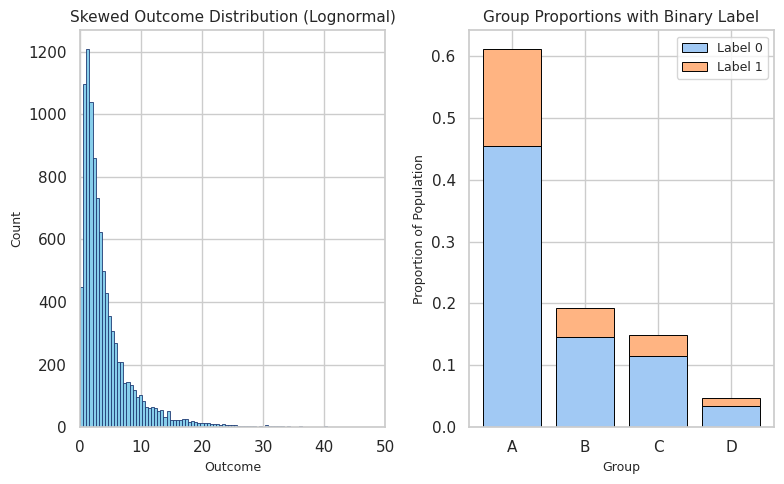

In [ ]:
# ============================================================
# Visualization for Simulated Population Data Generation
# Two charts: outcome distribution + group/label proportions
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", palette="pastel")

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

# ------------------------------------------------------------
# 1. Outcome distribution (skewed lognormal)
# ------------------------------------------------------------

bins = np.linspace(0, 50, 100)

axes[0].hist(
    df["outcome"],
    bins=bins,
    color="skyblue",
    edgecolor="#1f3b73",
    linewidth=0.6
)

axes[0].set_xlim(0, 50)
axes[0].set_title("Skewed Outcome Distribution (Lognormal)", fontsize=11)
axes[0].set_xlabel("Outcome", fontsize=9)
axes[0].set_ylabel("Count", fontsize=9)

# ------------------------------------------------------------
# 2. Group proportions with binary label split
# ------------------------------------------------------------

group_label_counts = (
    df.groupby(["group", "label"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

colors = sns.color_palette("pastel")
bottom = np.zeros(len(group_label_counts))

for i, label_val in enumerate([0, 1]):
    heights = group_label_counts[label_val] / len(df)
    axes[1].bar(
        group_label_counts.index,
        heights,
        bottom=bottom,
        color=colors[i],
        edgecolor="black",
        linewidth=0.7,
        label=f"Label {label_val}"
    )
    bottom += heights

axes[1].set_title("Group Proportions with Binary Label", fontsize=11)
axes[1].set_xlabel("Group", fontsize=9)
axes[1].set_ylabel("Proportion of Population", fontsize=9)
axes[1].legend(loc="upper right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_imbalanced_proportions")

## Sampling Distribution Generation via Repeated Samples

In [ ]:
# ============================================================
# Sampling Distribution (2000 samples of size 50, no replacement)
# ============================================================

# Sampling parameters
n_sample = 50
n_reps = 2000

np.random.seed(SEED)

# Generate repeated sample means
sample_means = np.array([
    np.mean(np.random.choice(pop, size=n_sample, replace=False))
    for _ in range(n_reps)
])

# Empirical sampling distribution stats
mu_hat = sample_means.mean()
sem_emp = sample_means.std(ddof=1)

# Population SD and theoretical SEM
sigma_pop = pop.std(ddof=1)
sem_theory = sigma_pop / np.sqrt(n_sample)

## Population vs. Sampling Distribution Statistics

In [ ]:
import pandas as pd
import numpy as np

# Population parameters
pop_mean = df["outcome"].mean()
pop_sd   = df["outcome"].std(ddof=0)

# Sampling distribution parameters
sampling_mean = sample_means.mean()
sampling_se_emp = sample_means.std(ddof=1)

# Theoretical SE
se_theoretical = pop_sd / np.sqrt(n_sample)

# Build comparison table
compare_df = pd.DataFrame({
    "Concept": [
        "Population mean vs Mean(sample means)",
        "Population SD vs Empirical SE",
        "Empirical SE vs Theoretical SE"
    ],
    "Population": [
        pop_mean,
        pop_sd,
        se_theoretical  # theoretical SE uses population SD
    ],
    "Empirical": [
        sampling_mean,
        sampling_se_emp,
        sampling_se_emp
    ]
})

print(compare_df.to_markdown(index=False))


| Concept                               |   Population |   Empirical |
|:--------------------------------------|-------------:|------------:|
| Population mean vs Mean(sample means) |     4.5288   |    4.54321  |
| Population SD vs Empirical SE         |     6.11224  |    0.885696 |
| Empirical SE vs Theoretical SE        |     0.864402 |    0.885696 |


## Central Limit Theorem and Empirical SEM

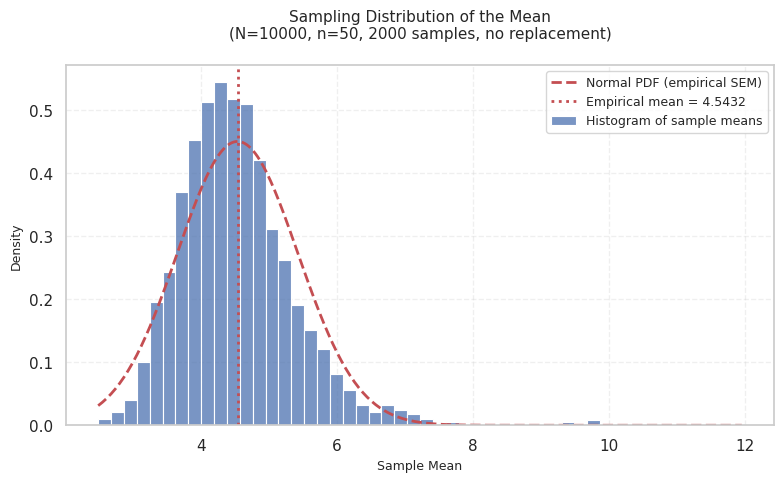

In [ ]:
# ============================================================
# CLT demonstration
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

fig, ax = plt.subplots(figsize=(8, 5))

# Histogram of sample means
sns.histplot(
    sample_means,
    bins=50,
    stat="density",
    color="#4C72B0",
    label="Histogram of sample means",
    ax=ax
)

# Normal PDF using empirical SEM
x = np.linspace(sample_means.min(), sample_means.max(), 300)
ax.plot(
    x,
    stats.norm.pdf(x, loc=mu_hat, scale=sem_emp),
    color="#C44E52",
    linestyle="--",
    linewidth=2,
    label="Normal PDF (empirical SEM)"
)

# Empirical mean line
ax.axvline(
    mu_hat,
    color="#C44E52",
    linestyle=":",
    linewidth=2,
    label=f"Empirical mean = {mu_hat:.4f}"
)

ax.set_title(
    "Sampling Distribution of the Mean\n(N=10000, n=50, 2000 samples, no replacement)",
    fontsize=11,
    y=1.05
)
ax.set_xlabel("Sample Mean", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
export_plot(fig, "sim_clt_demo", height=5)

## Sampling Distributions for Means, Proportions, Differences

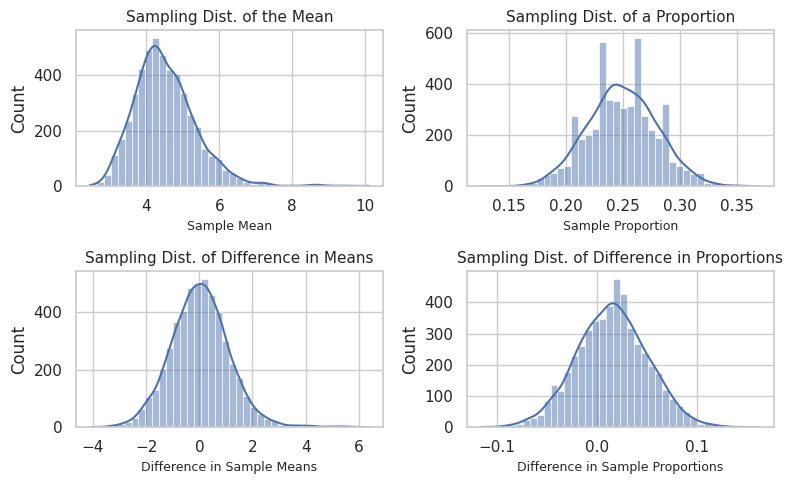

In [ ]:
# ============================================================
# Sampling Distributions Using the Canonical Dataset
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(SEED)
sns.set(style="whitegrid", palette="deep")

B = 5000   # number of repeated samples

# ------------------------------------------------------------
# 1. Sampling distribution of the mean
# ------------------------------------------------------------
n = 50
sample_means = [
    np.mean(np.random.choice(pop, n, replace=True))
    for _ in range(B)
]

# ------------------------------------------------------------
# 2. Sampling distribution of a proportion
# ------------------------------------------------------------
pop_binary = df["label"].values
n_prop = 200
sample_props = [
    np.mean(np.random.choice(pop_binary, n_prop, replace=True))
    for _ in range(B)
]

# ------------------------------------------------------------
# 3. Sampling distribution of a difference in means (A vs B)
# ------------------------------------------------------------
pop_A = df.loc[df["group"] == "A", "outcome"].values
pop_B = df.loc[df["group"] == "B", "outcome"].values

nA = nB = 60
diff_means = [
    np.mean(np.random.choice(pop_A, nA, replace=True)) -
    np.mean(np.random.choice(pop_B, nB, replace=True))
    for _ in range(B)
]

# ------------------------------------------------------------
# 4. Sampling distribution of a difference in proportions (A vs B)
# ------------------------------------------------------------
popA_bin = df.loc[df["group"] == "A", "label"].values
popB_bin = df.loc[df["group"] == "B", "label"].values

nA_bin = nB_bin = 300
diff_props = [
    np.mean(np.random.choice(popA_bin, nA_bin, replace=True)) -
    np.mean(np.random.choice(popB_bin, nB_bin, replace=True))
    for _ in range(B)
]

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(8, 5))

sns.histplot(sample_means, kde=True, bins=40, ax=axes[0, 0])
axes[0, 0].set_title("Sampling Dist. of the Mean", fontsize=11)
axes[0, 0].set_xlabel("Sample Mean", fontsize=9)

sns.histplot(sample_props, kde=True, bins=40, ax=axes[0, 1])
axes[0, 1].set_title("Sampling Dist. of a Proportion", fontsize=11)
axes[0, 1].set_xlabel("Sample Proportion", fontsize=9)

sns.histplot(diff_means, kde=True, bins=40, ax=axes[1, 0])
axes[1, 0].set_title("Sampling Dist. of Difference in Means", fontsize=11)
axes[1, 0].set_xlabel("Difference in Sample Means", fontsize=9)

sns.histplot(diff_props, kde=True, bins=40, ax=axes[1, 1])
axes[1, 1].set_title("Sampling Dist. of Difference in Proportions", fontsize=11)
axes[1, 1].set_xlabel("Difference in Sample Proportions", fontsize=9)

plt.tight_layout()
plt.show()
export_plot(fig, "sim_sampling_distributions")

## Finite Population Correction

Finite Population Correction Comparison:

 Population_N    n  SE_no_FPC  SE_with_FPC  Empirical_SE      FPC
        10000   50   0.864402     0.862281      0.882467 0.997547
        10000  200   0.432201     0.427879      0.432720 0.989999
        10000 1000   0.193286     0.183377      0.186273 0.948731
        10000 3000   0.111594     0.093371      0.093546 0.836702
        10000 6000   0.078909     0.049909      0.049590 0.632487


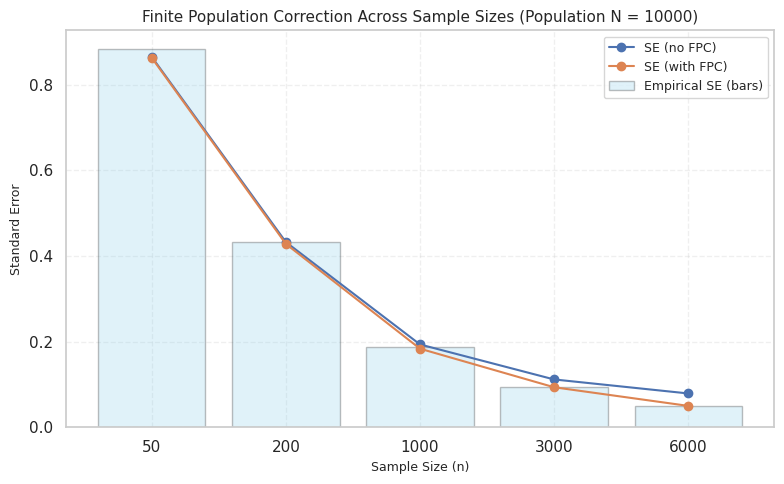

In [ ]:
# ============================================================
# Finite Population Correction Across Multiple Sample Sizes
# Visualization: 8x5 chart with empirical SE as bars
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(SEED)
sns.set(style="whitegrid")

# Sample sizes to compare
sample_sizes = [50, 200, 1000, 3000, 6000]   # spans small to large fractions of N
B = 3000                                     # repetitions for empirical SE

results = []

for n in sample_sizes:
    sigma = np.std(pop, ddof=0)

    # SE ignoring finite population
    se_no_fpc = sigma / np.sqrt(n)

    # Finite population correction factor
    fpc = np.sqrt((N - n) / (N - 1))

    # SE with FPC
    se_fpc = se_no_fpc * fpc

    # Empirical SE from sampling WITHOUT replacement
    sample_means = [
        np.mean(np.random.choice(pop, n, replace=False))
        for _ in range(B)
    ]
    empirical_se = np.std(sample_means, ddof=1)

    results.append([N, n, se_no_fpc, se_fpc, empirical_se, fpc])

# Convert to DataFrame
res_df = pd.DataFrame(
    results,
    columns=["Population_N", "n", "SE_no_FPC", "SE_with_FPC", "Empirical_SE", "FPC"]
)

print("Finite Population Correction Comparison:\n")
print(res_df.to_string(index=False))

# ------------------------------------------------------------
# Visualization (8x5, empirical SE as transparent bars)
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for empirical SE
ax.bar(
    res_df["n"].astype(str),
    res_df["Empirical_SE"],
    color="skyblue",
    alpha=0.25,
    edgecolor="black",
    linewidth=1.0,
    label="Empirical SE (bars)"
)

# Lines for theoretical SEs
ax.plot(res_df["n"].astype(str), res_df["SE_no_FPC"], marker="o", label="SE (no FPC)")
ax.plot(res_df["n"].astype(str), res_df["SE_with_FPC"], marker="o", label="SE (with FPC)")

ax.set_title(f"Finite Population Correction Across Sample Sizes (Population N = {N})", fontsize=11)
ax.set_xlabel("Sample Size (n)", fontsize=9)
ax.set_ylabel("Standard Error", fontsize=9)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
export_plot(fig, "sim_finite_population_correction", height=5)


## Exact Sampling Distributions for Inference

### t Distribution

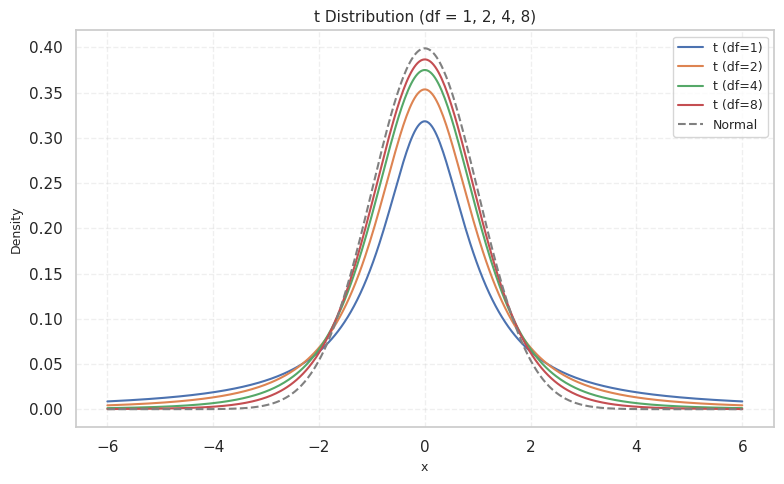

In [ ]:
# ============================================================
# t Distribution vs Normal Distribution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t, norm

x = np.linspace(-6, 6, 400)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, t.pdf(x, df=1), label="t (df=1)")
ax.plot(x, t.pdf(x, df=2), label="t (df=2)")
ax.plot(x, t.pdf(x, df=4), label="t (df=4)")
ax.plot(x, t.pdf(x, df=8), label="t (df=8)")
ax.plot(x, norm.pdf(x), label="Normal", linestyle="--", color="gray")

ax.set_title("t Distribution (df = 1, 2, 4, 8)", fontsize=11)
ax.set_xlabel("x", fontsize=9)
ax.set_ylabel("Density", fontsize=9)

ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
export_plot(fig, "sim_t_distribution")

### Chi-Square Distribution

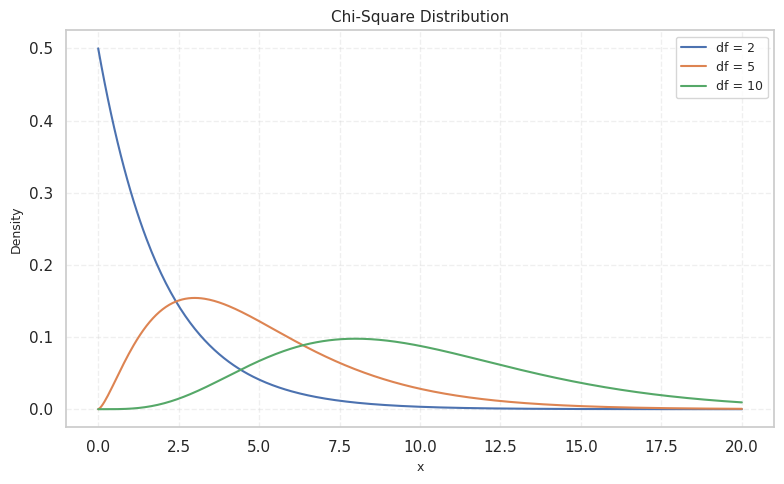

In [ ]:
# ============================================================
# Chi-Square Distribution (df = 2, 5, 10)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

x = np.linspace(0, 20, 400)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, chi2.pdf(x, df=2), label="df = 2")
ax.plot(x, chi2.pdf(x, df=5), label="df = 5")
ax.plot(x, chi2.pdf(x, df=10), label="df = 10")

ax.set_title("Chi-Square Distribution", fontsize=11)
ax.set_xlabel("x", fontsize=9)
ax.set_ylabel("Density", fontsize=9)

ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
export_plot(fig, "sim_chi_square_distribution", height=5)

### F Distribution

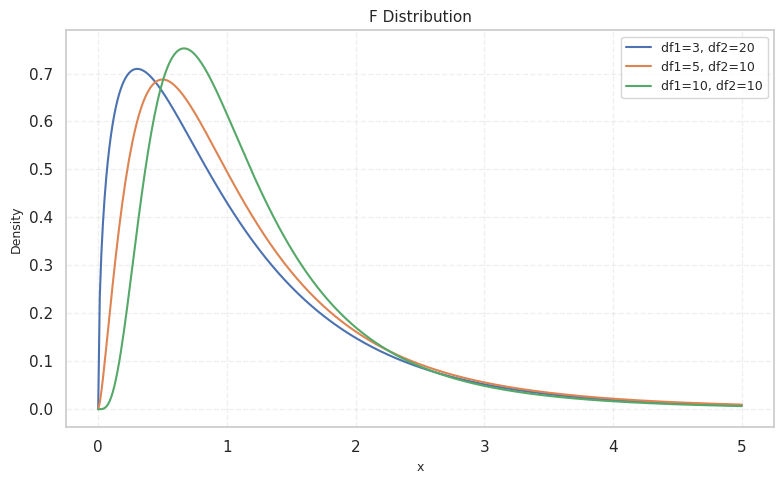

In [ ]:
# ============================================================
# F Distribution (df1 = 3,20 ; 5,10 ; 10,10)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

x = np.linspace(0, 5, 400)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, f.pdf(x, dfn=3, dfd=20), label="df1=3, df2=20")
ax.plot(x, f.pdf(x, dfn=5, dfd=10), label="df1=5, df2=10")
ax.plot(x, f.pdf(x, dfn=10, dfd=10), label="df1=10, df2=10")

ax.set_title("F Distribution", fontsize=11)
ax.set_xlabel("x", fontsize=9)
ax.set_ylabel("Density", fontsize=9)

ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
export_plot(fig, "sim_f_distribution")

## Bias-Variance Tradeoff

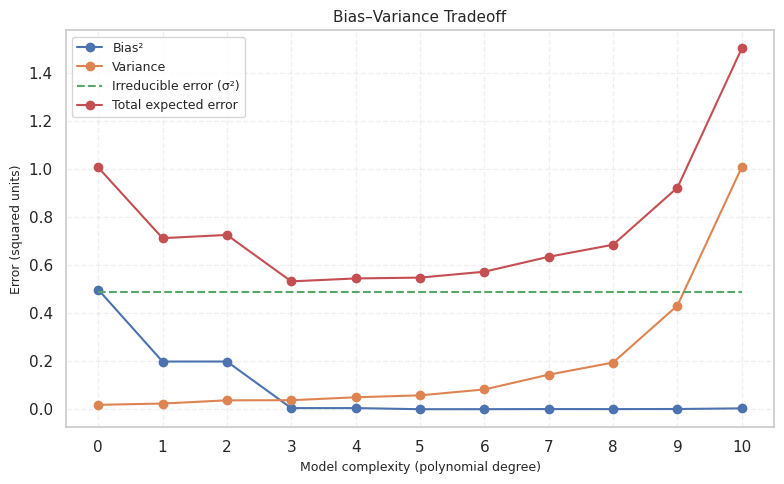

In [ ]:
# ============================================================
# Bias–Variance Tradeoff Simulation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

np.random.seed(SEED)

# True function
def f(x):
    return np.sin(2 * np.pi * x)

noise_sigma = 0.7

# Evaluation grid
x_grid = np.linspace(0, 1, 300).reshape(-1, 1)
f_true = f(x_grid)

# Simulation settings
n_train = 60
n_datasets = 250
degrees = range(0, 11)

bias2_list = []
var_list = []
total_error_list = []

for deg in degrees:
    preds = []

    poly = PolynomialFeatures(degree=deg, include_bias=True)
    model = LinearRegression()

    for _ in range(n_datasets):
        x_train = np.random.rand(n_train, 1)
        y_train = f(x_train) + noise_sigma * np.random.randn(n_train, 1)

        X_poly = poly.fit_transform(x_train)
        model.fit(X_poly, y_train)

        Xg_poly = poly.transform(x_grid)
        preds.append(model.predict(Xg_poly))

    preds = np.stack(preds, axis=0)
    mean_pred = preds.mean(axis=0)

    bias2 = ((mean_pred - f_true) ** 2).mean()
    var = preds.var(axis=0).mean()
    noise = noise_sigma**2

    bias2_list.append(bias2)
    var_list.append(var)
    total_error_list.append(bias2 + var + noise)

# ------------------------------------------------------------
# Visualization (8×5)
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(degrees, bias2_list, marker="o", label="Bias²")
ax.plot(degrees, var_list, marker="o", label="Variance")
ax.plot(degrees, [noise_sigma**2] * len(degrees),
        linestyle="--", label="Irreducible error (σ²)")
ax.plot(degrees, total_error_list, marker="o", label="Total expected error")

ax.set_xlabel("Model complexity (polynomial degree)", fontsize=9)
ax.set_ylabel("Error (squared units)", fontsize=9)
ax.set_title("Bias–Variance Tradeoff", fontsize=11)

ax.set_xticks(degrees)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()
export_plot(fig, "sim_bias_variance_tradeoff")